# Regression of Used Car Prices

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/playground-series-s4e9/sample_submission.csv
/kaggle/input/competitions/playground-series-s4e9/train.csv
/kaggle/input/competitions/playground-series-s4e9/test.csv


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge,Lasso
from sklearn.linear_model import ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.tree import ExtraTreeRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error


import warnings
warnings.filterwarnings('ignore')

In [3]:
train = pd.read_csv("/kaggle/input/competitions/playground-series-s4e9/train.csv")
test = pd.read_csv("/kaggle/input/competitions/playground-series-s4e9/test.csv")

In [4]:
print(train.shape)
print(test.shape)

(188533, 13)
(125690, 12)


In [5]:
train.head()

,id,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,0,MINI,Cooper S Base,2007,213000,Gasoline,172.0HP 1.6L 4 Cylinder Engine Gasoline Fuel,A/T,Yellow,Gray,None reported,Yes,4200
1,1,Lincoln,LS V8,2002,143250,Gasoline,252.0HP 3.9L 8 Cylinder Engine Gasoline Fuel,A/T,Silver,Beige,At least 1 accident or damage reported,Yes,4999
2,2,Chevrolet,Silverado 2500 LT,2002,136731,E85 Flex Fuel,320.0HP 5.3L 8 Cylinder Engine Flex Fuel Capab...,A/T,Blue,Gray,None reported,Yes,13900
3,3,Genesis,G90 5.0 Ultimate,2017,19500,Gasoline,420.0HP 5.0L 8 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,Black,Black,None reported,Yes,45000
4,4,Mercedes-Benz,Metris Base,2021,7388,Gasoline,208.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,7-Speed A/T,Black,Beige,None reported,Yes,97500


In [6]:
train.isnull().sum()

id                  0
brand               0
model               0
model_year          0
milage              0
fuel_type        5083
engine              0
transmission        0
ext_col             0
int_col             0
accident         2452
clean_title     21419
price               0
dtype: int64

In [7]:
test.isnull().sum()

id                  0
brand               0
model               0
model_year          0
milage              0
fuel_type        3383
engine              0
transmission        0
ext_col             0
int_col             0
accident         1632
clean_title     14239
dtype: int64

In [8]:
df=pd.concat([train,test]) 

## EDA

In [9]:
df.head(10)

,id,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,0,MINI,Cooper S Base,2007,213000,Gasoline,172.0HP 1.6L 4 Cylinder Engine Gasoline Fuel,A/T,Yellow,Gray,None reported,Yes,4200.0
1,1,Lincoln,LS V8,2002,143250,Gasoline,252.0HP 3.9L 8 Cylinder Engine Gasoline Fuel,A/T,Silver,Beige,At least 1 accident or damage reported,Yes,4999.0
2,2,Chevrolet,Silverado 2500 LT,2002,136731,E85 Flex Fuel,320.0HP 5.3L 8 Cylinder Engine Flex Fuel Capab...,A/T,Blue,Gray,None reported,Yes,13900.0
3,3,Genesis,G90 5.0 Ultimate,2017,19500,Gasoline,420.0HP 5.0L 8 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,Black,Black,None reported,Yes,45000.0
4,4,Mercedes-Benz,Metris Base,2021,7388,Gasoline,208.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,7-Speed A/T,Black,Beige,None reported,Yes,97500.0
5,5,Audi,A6 2.0T Sport,2018,40950,Gasoline,252.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,A/T,White,–,None reported,Yes,29950.0
6,6,Audi,A8 L 3.0T,2016,62200,Gasoline,333.0HP 3.0L V6 Cylinder Engine Gasoline Fuel,8-Speed A/T,Black,Black,None reported,Yes,28500.0
7,7,Chevrolet,Silverado 1500 1LZ,2016,102604,E85 Flex Fuel,355.0HP 5.3L 8 Cylinder Engine Flex Fuel Capab...,A/T,White,Gray,None reported,Yes,12500.0
8,8,Ford,F-150 XLT,2020,38352,Gasoline,2.7L V6 24V PDI DOHC Twin Turbo,10-Speed Automatic,Snowflake White Pearl Metallic,Black,None reported,Yes,62890.0
9,9,BMW,M4 Base,2015,74850,Gasoline,425.0HP 3.0L Straight 6 Cylinder Engine Gasoli...,Transmission w/Dual Shift Mode,Black,Blue,None reported,Yes,4000.0


In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,314223.0,157111.000000,90708.511155,0.0,78555.5,157111.0,235666.5,314222.0
model_year,314223.0,2015.817009,5.666116,1974.0,2013.0,2017.0,2020.0,2024.0
milage,314223.0,65840.210567,49969.067924,100.0,24213.0,57690.0,95500.0,405000.0
price,188533.0,43878.016178,78819.522254,2000.0,17000.0,30825.0,49900.0,2954083.0


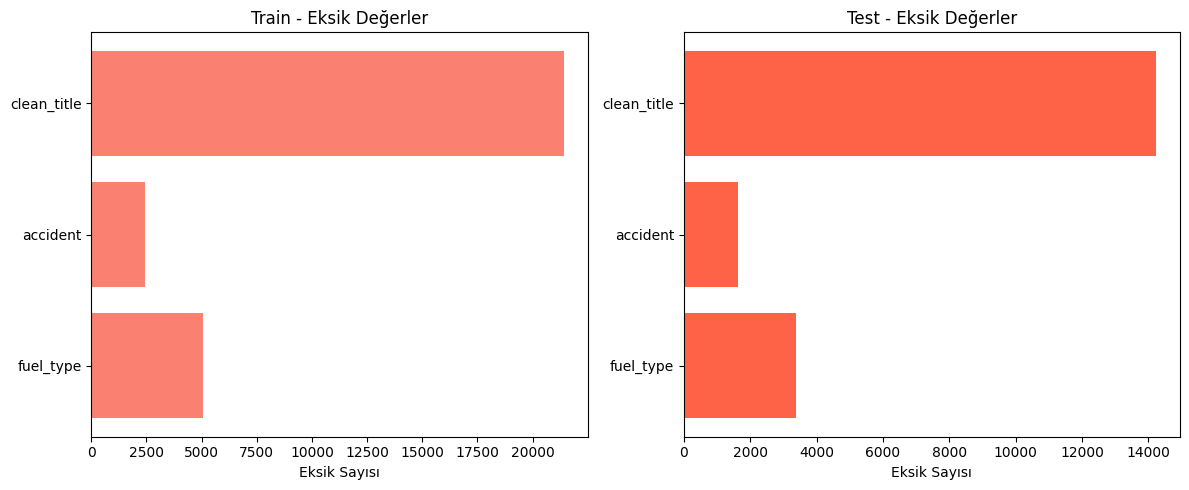

In [11]:
# Missing values
plt.figure(figsize=(12,5))

# Train
missing_train = train.isnull().sum()
missing_train = missing_train[missing_train > 0]

plt.subplot(1, 2, 1)
plt.barh(missing_train.index, missing_train.values, color='salmon')
plt.title('Train - Eksik Değerler')
plt.xlabel('Eksik Sayısı')

# Test
missing_test = test.isnull().sum()
missing_test = missing_test[missing_test > 0]

plt.subplot(1, 2, 2)
plt.barh(missing_test.index, missing_test.values, color='tomato')
plt.title('Test - Eksik Değerler')
plt.xlabel('Eksik Sayısı')


plt.tight_layout()
plt.show()

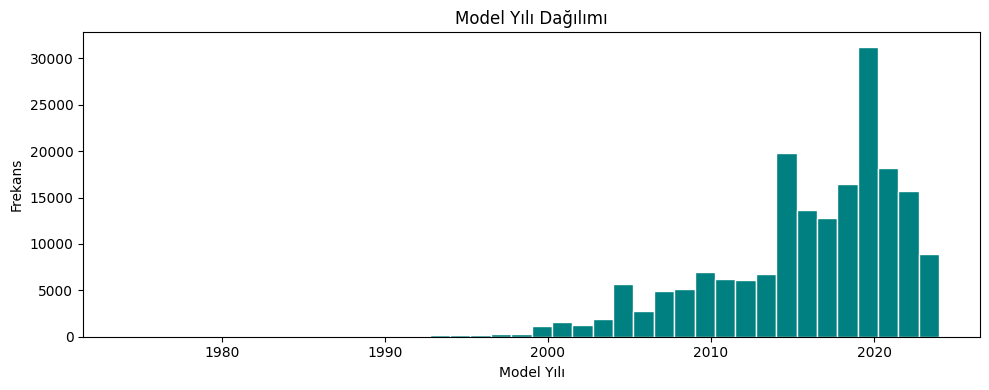

In [12]:
# Model Year Dağılımı
plt.figure(figsize=(10, 4))
plt.hist(train['model_year'], bins=40, color='teal', edgecolor='white')
plt.title('Model Yılı Dağılımı')
plt.xlabel('Model Yılı')
plt.ylabel('Frekans')
plt.tight_layout()
plt.show()

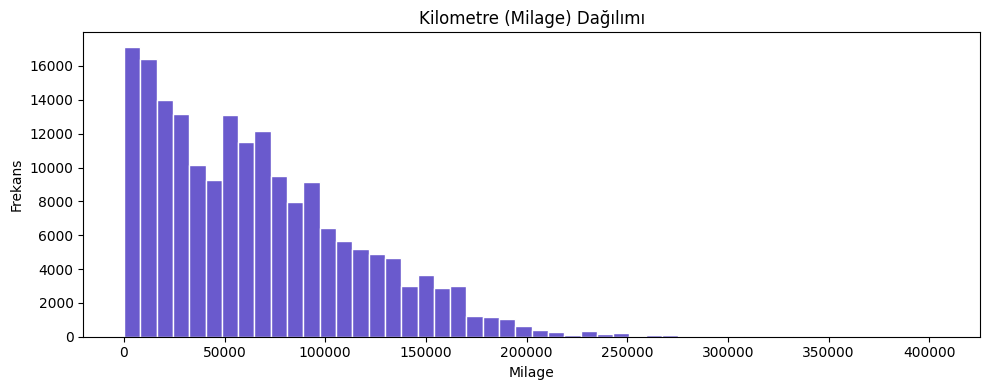

In [13]:
#  Milage Dağılımı
plt.figure(figsize=(10, 4))
plt.hist(train['milage'], bins=50, color='slateblue', edgecolor='white')
plt.title('Kilometre (Milage) Dağılımı')
plt.xlabel('Milage')
plt.ylabel('Frekans')
plt.tight_layout()
plt.show()

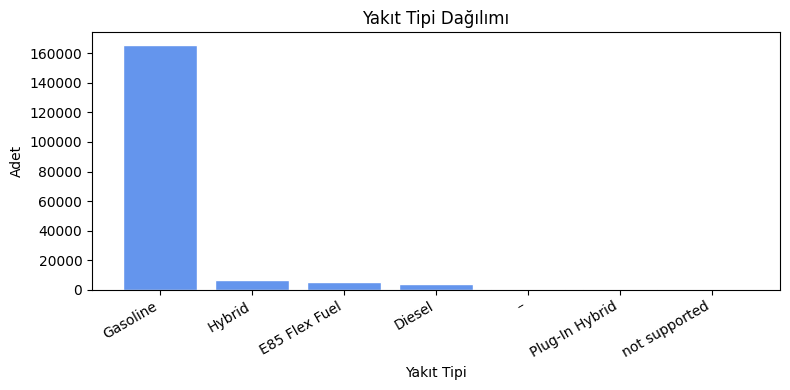

In [14]:
# Fuel Type Dağılımı
fuel_counts = train['fuel_type'].value_counts()

plt.figure(figsize=(8, 4))
plt.bar(fuel_counts.index, fuel_counts.values, color='cornflowerblue', edgecolor='white')
plt.title('Yakıt Tipi Dağılımı')
plt.xlabel('Yakıt Tipi')
plt.ylabel('Adet')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

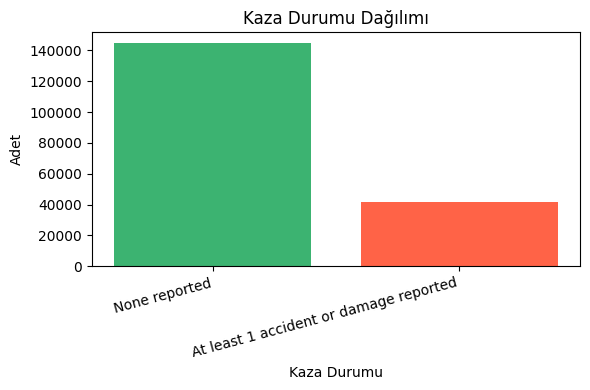

In [15]:
# Accident Dağılımı
accident_counts = train['accident'].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(accident_counts.index, accident_counts.values, color=['mediumseagreen', 'tomato'])
plt.title('Kaza Durumu Dağılımı')
plt.xlabel('Kaza Durumu')
plt.ylabel('Adet')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

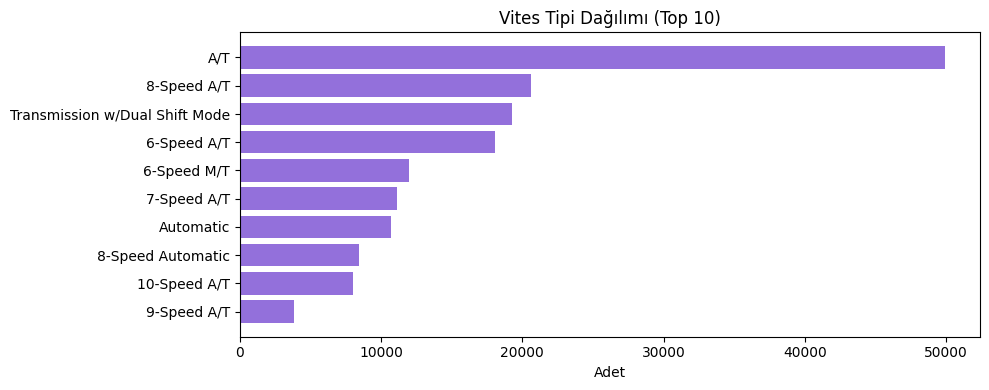

In [16]:
# Transmission Dağılımı
trans_counts = train['transmission'].value_counts().head(10)

plt.figure(figsize=(10, 4))
plt.barh(trans_counts.index[::-1], trans_counts.values[::-1], color='mediumpurple')
plt.title('Vites Tipi Dağılımı (Top 10)')
plt.xlabel('Adet')
plt.tight_layout()
plt.show()

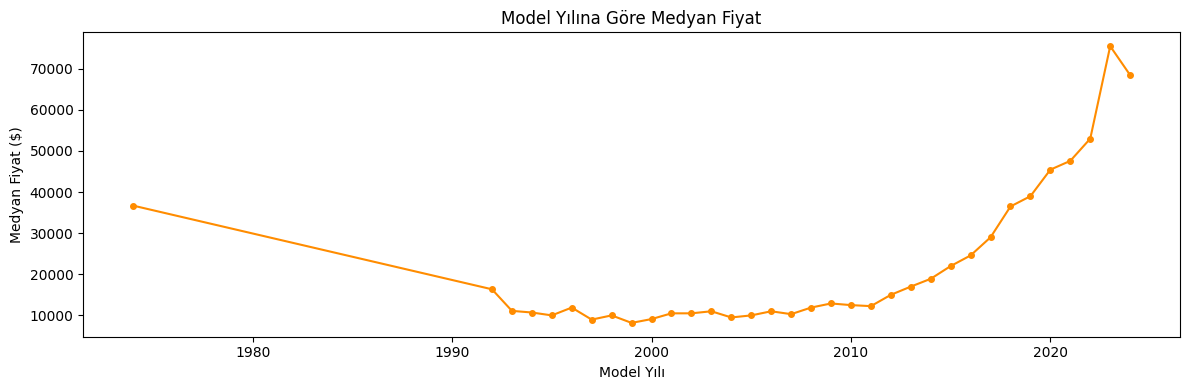

In [17]:
# Ortalama Fiyat - Model Yılı
avg_price_year = train.groupby('model_year')['price'].median().sort_index()

plt.figure(figsize=(12, 4))
plt.plot(avg_price_year.index, avg_price_year.values, color='darkorange', marker='o', markersize=4)
plt.title('Model Yılına Göre Medyan Fiyat')
plt.xlabel('Model Yılı')
plt.ylabel('Medyan Fiyat ($)')
plt.tight_layout()
plt.show()

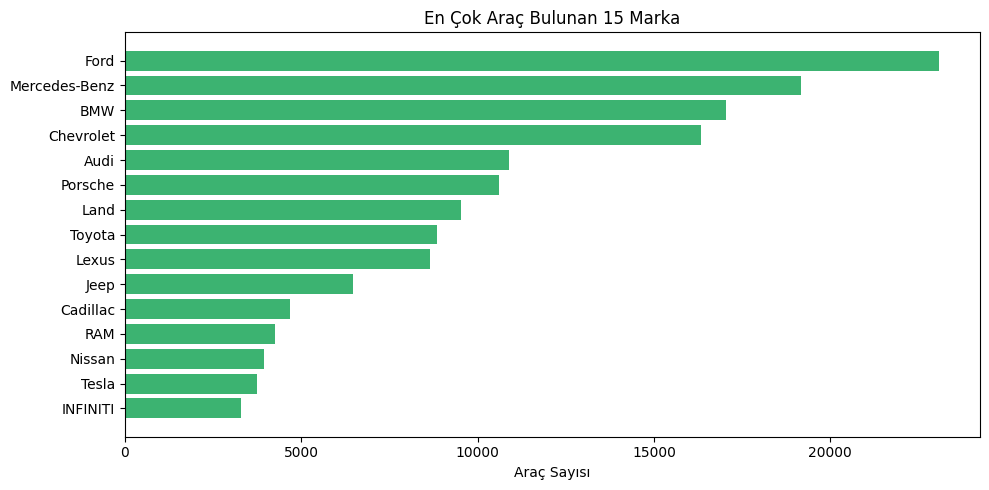

In [18]:
# En Çok Araç Bulunan 15 Marka
top_brands = train['brand'].value_counts().head(15)

plt.figure(figsize=(10, 5))
plt.barh(top_brands.index[::-1], top_brands.values[::-1], color='mediumseagreen')
plt.title('En Çok Araç Bulunan 15 Marka')
plt.xlabel('Araç Sayısı')
plt.tight_layout()
plt.show()

# Data Processing & Feature Engineering

In [19]:
df.isnull().sum()

id                   0
brand                0
model                0
model_year           0
milage               0
fuel_type         8466
engine               0
transmission         0
ext_col              0
int_col              0
accident          4084
clean_title      35658
price           125690
dtype: int64

In [20]:
# fuel_type
def extract_fuel_from_engine(engine_str):
    engine_str = str(engine_str).lower()
    if 'electric' in engine_str:
        return 'Electric'
    elif 'diesel' in engine_str:
        return 'Diesel'
    elif 'hybrid' in engine_str or 'mild' in engine_str:
        return 'Hybrid'
    elif 'flex' in engine_str or 'e85' in engine_str:
        return 'E85 Flex Fuel'
    elif 'gasoline' in engine_str:
        return 'Gasoline'
    else:
        return np.nan

df['fuel_type'] = df.apply(
    lambda row: extract_fuel_from_engine(row['engine'])
    if pd.isnull(row['fuel_type']) else row['fuel_type'],
    axis=1
)

In [21]:
df['fuel_type'].isnull().sum()

np.int64(288)

In [22]:
# aynı brand + model içindeki mod ile dolduracağız
def fill_mode(x):
    mode = x.mode()
    return x.fillna(mode[0]) if len(mode) else x

df['fuel_type'] = df.groupby(['brand', 'model'])['fuel_type'].transform(fill_mode)

In [23]:
df['fuel_type'].isnull().sum()

np.int64(4)

In [24]:
df['fuel_type'].fillna(df['fuel_type'].mode()[0], inplace=True)

In [25]:
#ACCIDENT 
df['accident'].fillna('Unknown', inplace=True)

In [26]:
# CLEAN_TITLE
df['clean_title'].fillna('Unknown', inplace=True)

In [27]:
df.isnull().sum()

id                   0
brand                0
model                0
model_year           0
milage               0
fuel_type            0
engine               0
transmission         0
ext_col              0
int_col              0
accident             0
clean_title          0
price           125690
dtype: int64

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 314223 entries, 0 to 125689
Data columns (total 13 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            314223 non-null  int64  
 1   brand         314223 non-null  object 
 2   model         314223 non-null  object 
 3   model_year    314223 non-null  int64  
 4   milage        314223 non-null  int64  
 5   fuel_type     314223 non-null  object 
 6   engine        314223 non-null  object 
 7   transmission  314223 non-null  object 
 8   ext_col       314223 non-null  object 
 9   int_col       314223 non-null  object 
 10  accident      314223 non-null  object 
 11  clean_title   314223 non-null  object 
 12  price         188533 non-null  float64
dtypes: float64(1), int64(3), object(9)
memory usage: 33.6+ MB


In [29]:
df.engine.value_counts()

engine
355.0HP 5.3L 8 Cylinder Engine Gasoline Fuel           5651
240.0HP 2.0L 4 Cylinder Engine Gasoline Fuel           4868
420.0HP 6.2L 8 Cylinder Engine Gasoline Fuel           4694
2.0L I4 16V GDI DOHC Turbo                             4513
375.0HP 3.5L V6 Cylinder Engine Gasoline Fuel          4090
                                                       ... 
70.0HP 1.0L 3 Cylinder Engine Gasoline Fuel               3
111.0HP Electric Motor Electric Fuel System               3
139.0HP 1.6L 4 Cylinder Engine Plug-In Electric/Gas       3
78.0HP 1.2L 3 Cylinder Engine Gasoline Fuel               2
313.0HP 2.0L 4 Cylinder Engine Plug-In Electric/Gas       1
Name: count, Length: 1118, dtype: int64

In [30]:
df['horsepower'] = df['engine'].str.extract(r'(\d+\.?\d*)HP').astype(float)
df['engine_size'] = df['engine'].str.extract(r'(\d+\.?\d*)L').astype(float)
df['cylinders']   = df['engine'].str.extract(r'(\d+)\s*Cylinder').astype(float)

In [31]:
## car age
df['car_age'] = 2026 - df['model_year']

In [32]:
# milage_per_year
df['milage_per_year'] = df['milage'] / df['car_age'].replace(0, 1)

In [33]:
df['has_accident']  = (df['accident'] == 'At least 1 accident or damage reported').astype(int)
df['is_clean_title'] = (df['clean_title'] == 'Yes').astype(int)

In [34]:
# automatic transmission
df['is_automatic'] = df['transmission'].str.contains('A/T|Automatic|CVT', case=False, na=False).astype(int)

In [35]:
luxury_brands = ['BMW', 'Mercedes-Benz', 'Audi', 'Porsche', 'Lamborghini',
                 'Ferrari', 'Bentley', 'Rolls-Royce', 'Maserati', 'Genesis',
                 'Lexus', 'Cadillac', 'Lincoln', 'Land', 'Volvo', 'Jaguar']

df['is_luxury'] = df['brand'].isin(luxury_brands).astype(int)

In [36]:
# power / cylinder rate
df['hp_per_cylinder'] = df['horsepower'] / df['cylinders'].replace(0, np.nan)
df['hp_per_cylinder'].fillna(df['hp_per_cylinder'].median(), inplace=True)

In [37]:
df.isnull().sum()

id                      0
brand                   0
model                   0
model_year              0
milage                  0
fuel_type               0
engine                  0
transmission            0
ext_col                 0
int_col                 0
accident                0
clean_title             0
price              125690
horsepower          55440
engine_size         23621
cylinders           63005
car_age                 0
milage_per_year         0
has_accident            0
is_clean_title          0
is_automatic            0
is_luxury               0
hp_per_cylinder         0
dtype: int64

In [38]:
df['horsepower']  = df.groupby(['brand', 'model'])['horsepower'].transform(lambda x: x.fillna(x.median()))
df['engine_size'] = df.groupby(['brand', 'model'])['engine_size'].transform(lambda x: x.fillna(x.median()))
df['cylinders']   = df.groupby(['brand', 'model'])['cylinders'].transform(lambda x: x.fillna(x.median()))

In [39]:
df.isnull().sum()

id                      0
brand                   0
model                   0
model_year              0
milage                  0
fuel_type               0
engine                  0
transmission            0
ext_col                 0
int_col                 0
accident                0
clean_title             0
price              125690
horsepower            749
engine_size          1880
cylinders            5349
car_age                 0
milage_per_year         0
has_accident            0
is_clean_title          0
is_automatic            0
is_luxury               0
hp_per_cylinder         0
dtype: int64

In [40]:
df['horsepower']  = df.groupby('brand')['horsepower'].transform(lambda x: x.fillna(x.median()))
df['engine_size'] = df.groupby('brand')['engine_size'].transform(lambda x: x.fillna(x.median()))
df['cylinders']   = df.groupby('brand')['cylinders'].transform(lambda x: x.fillna(x.median()))

In [41]:
df.isnull().sum()

id                      0
brand                   0
model                   0
model_year              0
milage                  0
fuel_type               0
engine                  0
transmission            0
ext_col                 0
int_col                 0
accident                0
clean_title             0
price              125690
horsepower             10
engine_size             0
cylinders              10
car_age                 0
milage_per_year         0
has_accident            0
is_clean_title          0
is_automatic            0
is_luxury               0
hp_per_cylinder         0
dtype: int64

In [42]:
df['horsepower'].fillna(df['horsepower'].median(), inplace=True)
df['engine_size'].fillna(df['engine_size'].median(), inplace=True)
df['cylinders'].fillna(df['cylinders'].median(), inplace=True)

In [43]:
df.isnull().sum()

id                      0
brand                   0
model                   0
model_year              0
milage                  0
fuel_type               0
engine                  0
transmission            0
ext_col                 0
int_col                 0
accident                0
clean_title             0
price              125690
horsepower              0
engine_size             0
cylinders               0
car_age                 0
milage_per_year         0
has_accident            0
is_clean_title          0
is_automatic            0
is_luxury               0
hp_per_cylinder         0
dtype: int64

In [44]:
#Correlation by price
abs(df.corr(numeric_only=True))['price'].sort_values(ascending=False)

price              1.000000
milage             0.283067
horsepower         0.252842
car_age            0.231795
model_year         0.231795
milage_per_year    0.191553
hp_per_cylinder    0.175468
cylinders          0.134720
has_accident       0.125122
engine_size        0.094389
is_luxury          0.090463
is_clean_title     0.089433
is_automatic       0.005159
id                 0.000877
Name: price, dtype: float64

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 314223 entries, 0 to 125689
Data columns (total 23 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   id               314223 non-null  int64  
 1   brand            314223 non-null  object 
 2   model            314223 non-null  object 
 3   model_year       314223 non-null  int64  
 4   milage           314223 non-null  int64  
 5   fuel_type        314223 non-null  object 
 6   engine           314223 non-null  object 
 7   transmission     314223 non-null  object 
 8   ext_col          314223 non-null  object 
 9   int_col          314223 non-null  object 
 10  accident         314223 non-null  object 
 11  clean_title      314223 non-null  object 
 12  price            188533 non-null  float64
 13  horsepower       314223 non-null  float64
 14  engine_size      314223 non-null  float64
 15  cylinders        314223 non-null  float64
 16  car_age          314223 non-null  int64  
 

## Train Test Split

In [46]:
train = df[df['price'].notna()]
test  = df[df['price'].isna()]

In [47]:
x = train.drop(['id', 'engine', 'price'], axis=1)

y = train['price']


x_final_test = test.drop(['id', 'engine', 'price'], axis=1)

In [48]:
x_all = pd.concat([x, x_final_test])
x_all = pd.get_dummies(x_all, drop_first=True)

In [49]:
x = x_all.iloc[:len(x)]
x_final_test = x_all.iloc[len(x):]

## Model Training

In [50]:
def algo_test(x, y):

    linear_models = {
        'LinearRegression' : LinearRegression(),
        'Ridge'            : Ridge(),
        'Lasso'            : Lasso(),
        'ElasticNet'       : ElasticNet(),
    }

    tree_models = {
        'DecisionTree'  : DecisionTreeRegressor(random_state=42),
        'ExtraTrees'    : ExtraTreesRegressor(n_jobs=-1, random_state=42),
        'XGBoost'       : XGBRegressor(n_jobs=-1, random_state=42, verbosity=0),
        'LightGBM'      : LGBMRegressor(n_jobs=-1, random_state=42, verbose=-1),
    }

    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

    scaler = StandardScaler()
    x_train_scaled = scaler.fit_transform(x_train)
    x_test_scaled  = scaler.transform(x_test)

    results = []

    for name, model in linear_models.items():
        model.fit(x_train_scaled, y_train)
        p = model.predict(x_test_scaled)
        results.append({
            'Model' : name,
            'R²'    : round(r2_score(y_test, p), 4),
            'RMSE'  : round(mean_squared_error(y_test, p) ** 0.5, 2),
            'MAE'   : round(mean_absolute_error(y_test, p), 2)
        })
        print(f"✅ {name} tamamlandı")

    for name, model in tree_models.items():
        model.fit(x_train, y_train)
        p = model.predict(x_test)
        results.append({
            'Model' : name,
            'R²'    : round(r2_score(y_test, p), 4),
            'RMSE'  : round(mean_squared_error(y_test, p) ** 0.5, 2),
            'MAE'   : round(mean_absolute_error(y_test, p), 2)
        })
        print(f"✅ {name} tamamlandı")

    result_df = pd.DataFrame(results).set_index('Model')
    return result_df.sort_values('R²', ascending=False)

In [51]:
algo_test(x, y)

✅ LinearRegression tamamlandı
✅ Ridge tamamlandı
✅ Lasso tamamlandı
✅ ElasticNet tamamlandı
✅ DecisionTree tamamlandı
✅ ExtraTrees tamamlandı
✅ XGBoost tamamlandı
✅ LightGBM tamamlandı


,R²,RMSE,MAE
Model,,,
LightGBM,0.1644,68166.09,19719.31
ElasticNet,0.1471,68871.76,20815.77
Lasso,0.1397,69167.27,21482.25
Ridge,0.1396,69171.82,21492.06
LinearRegression,0.1396,69171.86,21492.12
XGBoost,-0.0024,74663.55,20139.03
ExtraTrees,-0.1569,80211.14,21715.11
DecisionTree,-1.0565,106941.81,26731.32


In [52]:
best_model= LGBMRegressor(n_jobs=-1, random_state=42, verbose=-1)
best_model.fit(x,y)

LGBMRegressor(n_jobs=-1, random_state=42, verbose=-1)

In [53]:
prediction= best_model.predict(x_final_test)

In [54]:
submission = pd.DataFrame({
    'id'    : test['id'].values,
    'price' : prediction
})

In [55]:
submission.head(10)

,id,price
0,188533,17365.023308
1,188534,77999.192815
2,188535,56126.483404
3,188536,23470.580512
4,188537,31163.452243
5,188538,15073.405748
6,188539,12665.843039
7,188540,42609.574099
8,188541,94170.401573
9,188542,33127.503695


In [56]:
submission.to_csv('submission.csv', index=False)